In [5]:
import pandas as pd

df = pd.read_csv("../data/raw/chicago_crimes.csv", nrows=100000)

print(df.shape)
df.head()

(100000, 22)


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,13311263,JG503434,07/29/2022 03:39:00 AM,023XX S TROY ST,1582,OFFENSE INVOLVING CHILDREN,CHILD PORNOGRAPHY,RESIDENCE,True,False,...,25.0,30.0,17,NaN,NaN,2022,04/18/2024 03:40:59 PM,NaN,NaN,NaN
1,13053066,JG103252,01/03/2023 04:44:00 PM,039XX W WASHINGTON BLVD,2017,NARCOTICS,MANUFACTURE / DELIVER - CRACK,SIDEWALK,True,False,...,28.0,26.0,18,NaN,NaN,2023,01/20/2024 03:41:12 PM,NaN,NaN,NaN
2,12131221,JD327000,08/10/2020 09:45:00 AM,015XX N DAMEN AVE,0326,ROBBERY,AGGRAVATED VEHICULAR HIJACKING,STREET,True,False,...,1.0,24.0,03,1162795.0,1909900.0,2020,05/17/2025 03:40:52 PM,41.908418,-87.677407,"(41.908417822, -87.67740693)"
3,11227634,JB147599,08/26/2017 10:00:00 AM,001XX W RANDOLPH ST,0281,CRIM SEXUAL ASSAULT,NON-AGGRAVATED,HOTEL/MOTEL,False,False,...,42.0,32.0,02,NaN,NaN,2017,02/11/2018 03:57:41 PM,NaN,NaN,NaN
4,13203321,JG415333,09/06/2023 05:00:00 PM,002XX N Wells st,1320,CRIMINAL DAMAGE,TO VEHICLE,PARKING LOT / GARAGE (NON RESIDENTIAL),False,False,...,42.0,32.0,14,1174694.0,1901831.0,2023,11/04/2023 03:40:18 PM,41.886018,-87.633938,"(41.886018055, -87.633937881)"


In [6]:
df.columns

Index(['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type',
       'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat',
       'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate',
       'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude',
       'Location'],
      dtype='str')

In [7]:
columns = [
    "Date",
    "Primary Type",
    "Latitude",
    "Longitude",
    "District",
    "Community Area"
]

df = df[columns]

df.head()

,Date,Primary Type,Latitude,Longitude,District,Community Area
0,07/29/2022 03:39:00 AM,OFFENSE INVOLVING CHILDREN,NaN,NaN,10,30.0
1,01/03/2023 04:44:00 PM,NARCOTICS,NaN,NaN,11,26.0
2,08/10/2020 09:45:00 AM,ROBBERY,41.908418,-87.677407,14,24.0
3,08/26/2017 10:00:00 AM,CRIM SEXUAL ASSAULT,NaN,NaN,1,32.0
4,09/06/2023 05:00:00 PM,CRIMINAL DAMAGE,41.886018,-87.633938,1,32.0


In [8]:
df.isnull().sum()

Date                 0
Primary Type         0
Latitude          9105
Longitude         9105
District             0
Community Area    2554
dtype: int64

In [9]:
df = df.dropna(subset=["Latitude", "Longitude"])

df.shape

(90895, 6)

In [10]:
df["Date"] = pd.to_datetime(df["Date"])

In [11]:
df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["day"] = df["Date"].dt.day
df["hour"] = df["Date"].dt.hour
df["day_of_week"] = df["Date"].dt.day_name()

df.head()

,Date,Primary Type,Latitude,Longitude,District,Community Area,year,month,day,hour,day_of_week
2,2020-08-10 09:45:00,ROBBERY,41.908418,-87.677407,14,24.0,2020,8,10,9,Monday
4,2023-09-06 17:00:00,CRIMINAL DAMAGE,41.886018,-87.633938,1,32.0,2023,9,6,17,Wednesday
5,2023-09-06 11:00:00,THEFT,41.871835,-87.626151,1,32.0,2023,9,6,11,Wednesday
6,2019-05-21 08:20:00,BURGLARY,41.856547,-87.695605,10,29.0,2019,5,21,8,Tuesday
7,2021-07-07 10:30:00,SEX OFFENSE,41.655116,-87.594883,5,54.0,2021,7,7,10,Wednesday


Matplotlib is building the font cache; this may take a moment.


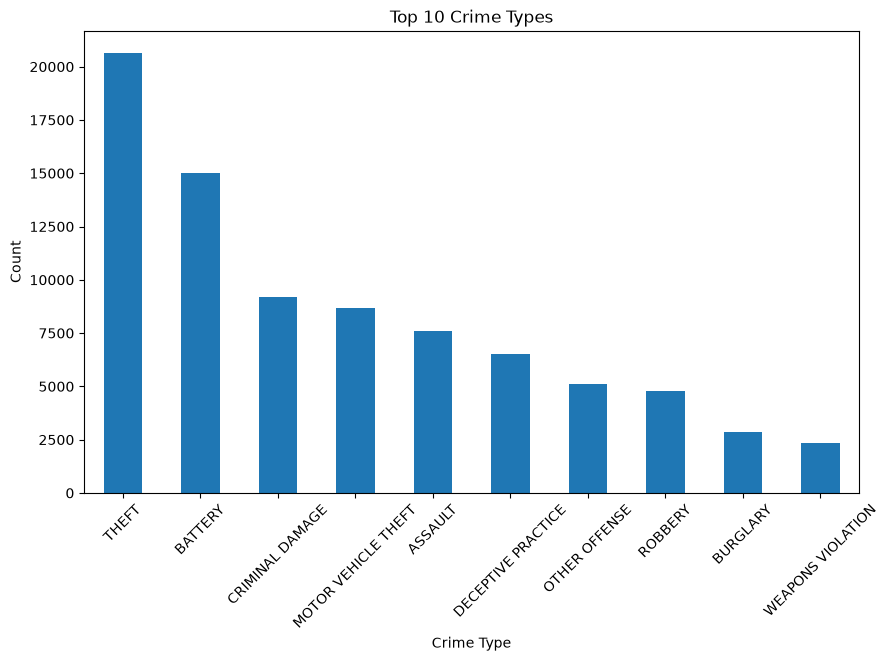

In [12]:
import matplotlib.pyplot as plt

top_crimes = df["Primary Type"].value_counts().head(10)

plt.figure(figsize=(10,6))
top_crimes.plot(kind="bar")
plt.title("Top 10 Crime Types")
plt.xlabel("Crime Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

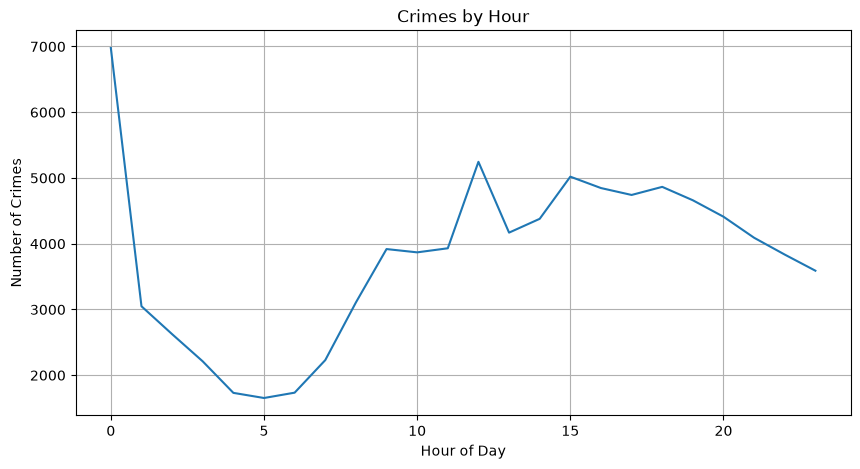

In [13]:
hourly = df["hour"].value_counts().sort_index()

plt.figure(figsize=(10,5))
hourly.plot()
plt.title("Crimes by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Crimes")
plt.grid()
plt.show()

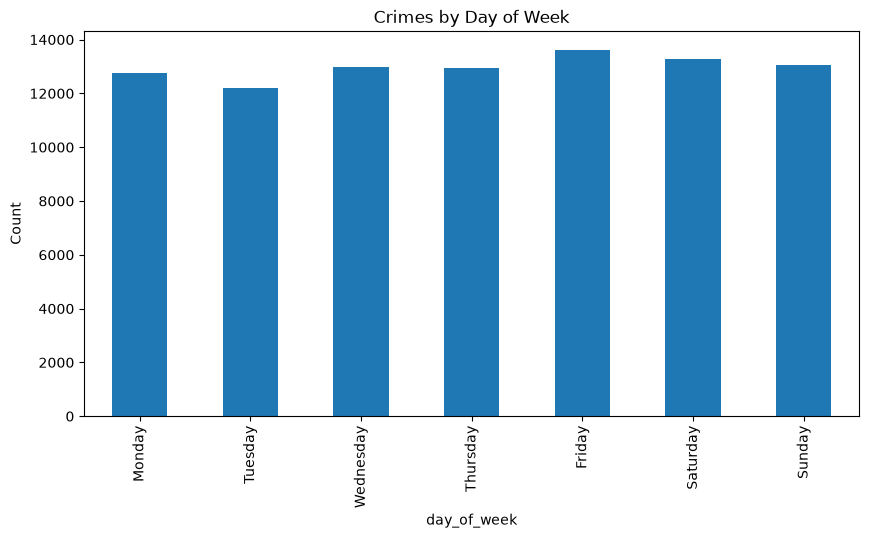

In [14]:
days_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_counts = df["day_of_week"].value_counts().reindex(days_order)

plt.figure(figsize=(10,5))
day_counts.plot(kind="bar")
plt.title("Crimes by Day of Week")
plt.ylabel("Count")
plt.show()